In [12]:
import numpy as np
import matplotlib.pyplot as plt
import dwfpy as dwf
from tqdm import tqdm
import time

In [13]:
# Frequency sweep
fs = 10e6
pulse_v = 1.0
f0_guess = 2.5e6
record_s = 500e-6

with dwf.Device() as device:
    print(f"Found device: {device.name} ({device.serial_number})")

    scope = device.analog_input
    wavegen = device.analog_output

    scope.reset()
    scope[1].setup(range=pulse_v)
    scope.setup_edge_trigger(mode='normal', channel=1, slope='rising', level=0.1, hysteresis=0.01)

    wavegen[0].reset()
    wavegen[0].setup("sine", frequency=f0_guess, amplitude=pulse_v, start=True)

    
    recorder = scope.record(sample_rate=fs, length=record_s, configure=True, start=True)
    if recorder.lost_samples > 0:
        print("Samples lost, reduce sample rate.")
    if recorder.corrupted_samples > 0:
        print("Samples corrupted, reduce sample rate.")

    print(
        f"Processed {recorder.total_samples} samples total, "
        f"received {len(recorder.channels[0].data_samples)} samples."
    )
    channels = recorder.channels

ch1_val = np.array(channels[1].data_samples)

Found device: Analog Discovery 2 (210321A80279)
Processed 5000 samples total, received 5000 samples.


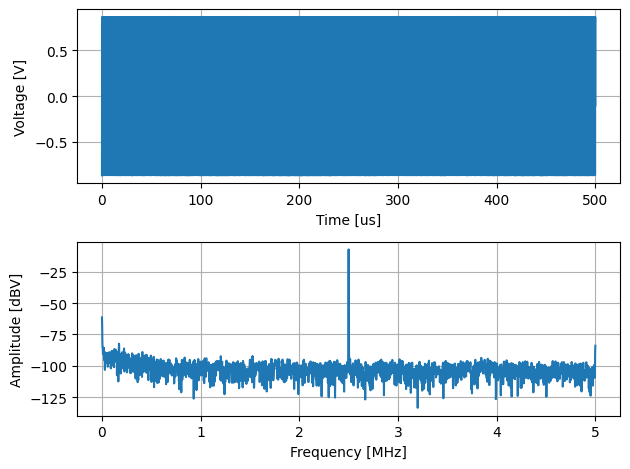

In [14]:
t = np.arange(len(ch1_val)) / fs
freqs = np.fft.rfftfreq(len(ch1_val), 1 / fs)

window = np.hanning(len(ch1_val))
fft_ch1 = np.abs(np.fft.rfft(ch1_val * window)) / (len(ch1_val) * 0.5)

plt.subplot(2, 1, 1)
plt.plot(t * 1e6, ch1_val)
plt.xlabel('Time [us]')
plt.ylabel('Voltage [V]')
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(freqs / 1e6, 20 * np.log10(fft_ch1 + 1e-12))
plt.xlabel('Frequency [MHz]')
plt.ylabel('Amplitude [dBV]')
plt.grid()

plt.tight_layout()
plt.show()

In [39]:
# Sweep parameters
pulse_v_min = 0.1
pulse_v_max = 2.0
n_amp = 100

f0_guess = 2.5e6
f_span = 4e6
n_freq = 500

# Acquisition
fs = 10e6
record_s = 500e-6

# Derived axes
freq_axis = np.linspace(f0_guess - f_span / 2, f0_guess + f_span / 2, n_freq)
amp_axis = np.linspace(pulse_v_min, pulse_v_max, n_amp)
total_shots = n_freq * n_amp


In [87]:
file = 'h2_tube_3'

# Sweep
energy_map = np.zeros((n_amp, n_freq))

with dwf.Device() as device:
    print(f"Found device: {device.name} ({device.serial_number})")

    scope = device.analog_input
    wavegen = device.analog_output

    scope.reset()
    scope[1].setup(range=pulse_v_max)
    scope.setup_edge_trigger(mode='normal', channel=1, slope='rising', level=0.01, hysteresis=0.01)

    with tqdm(total=total_shots, unit='shot') as pbar:
        for i_f, freq in enumerate(freq_axis):
            for i_a, amp in enumerate(amp_axis):
                try:
                    wavegen[0].setup("sine", frequency=freq, amplitude=amp, start=True)
                    time.sleep(0.001)
                    rec = scope.record(sample_rate=fs, length=record_s, configure=True, start=True)
                    ch1 = np.array(rec.channels[1].data_samples)
                    e = float(np.mean(ch1 ** 2))
                except Exception as ex:
                    tqdm.write(f'WARN shot ({i_f},{i_a}) failed: {ex}')
                    e = 0.0

                energy_map[i_a, i_f] = e
                pbar.set_postfix(f=f'{freq/1e6:.4f}MHz', amp=f'{amp:.2f}V', E=f'{e*1e6:.2f}µV²')
                pbar.update(1)

# Save
np.savez('data/'+file+'.npz', energy_map=energy_map, freq_axis=freq_axis, amp_axis=amp_axis)
print('Saved!')

Found device: Analog Discovery 2 (210321A80279)


100%|██████████| 50000/50000 [04:18<00:00, 193.20shot/s, E=568.59µV², amp=2.00V, f=4.5000MHz]  


Saved!


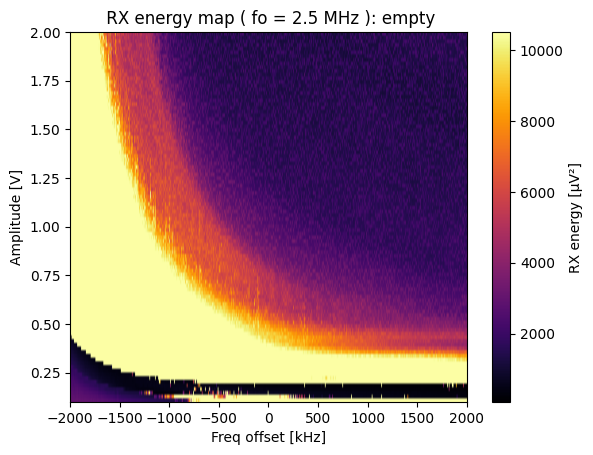

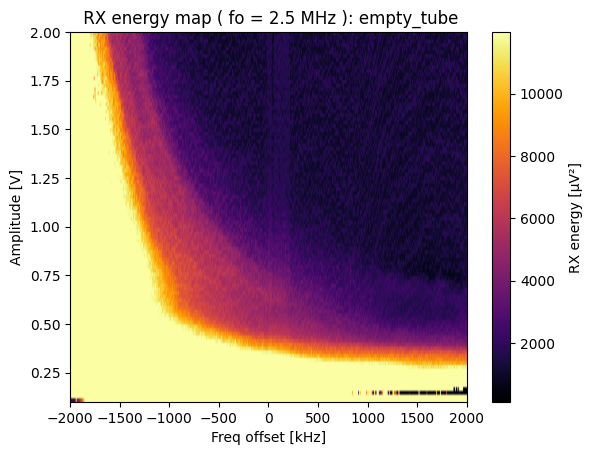

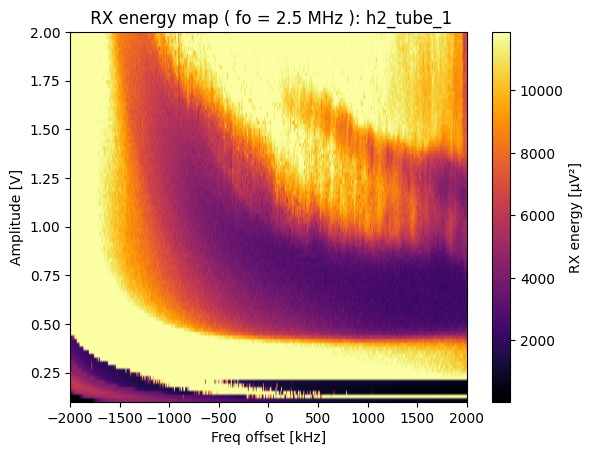

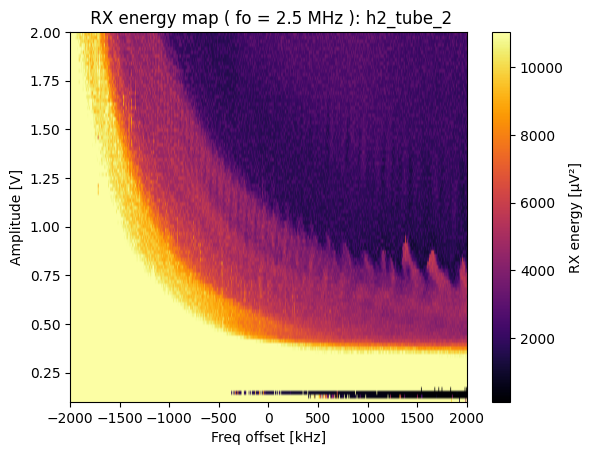

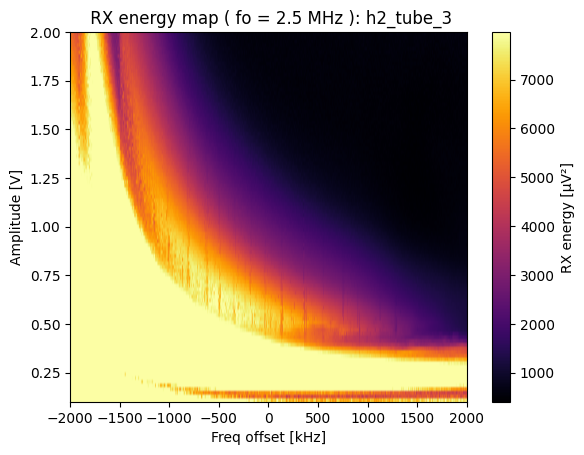

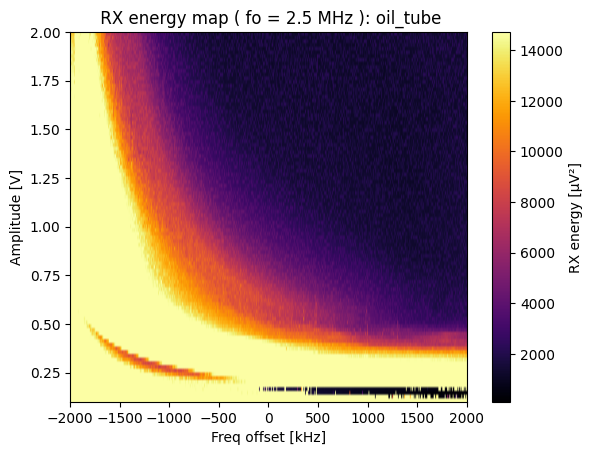

In [90]:
files = ['empty', 'empty_tube', 'h2_tube_1', 'h2_tube_2', 'h2_tube_3', 'oil_tube']
for file in files:
        try:
                d = np.load('data/'+file+'.npz')
        except:
                continue
        energy_map = d['energy_map']
        freq_axis  = d['freq_axis']
        amp_axis   = d['amp_axis']

        # Analysis
        freq_profile = energy_map.mean(axis=0)
        amp_profile = energy_map.mean(axis=1)
        i_f0 = np.argmin(freq_profile)
        # f0_est = freq_axis[i_f0]

        # print(f'Estimated resonance frequency: {f0_est/1e6:.4f} MHz')

        # Energy map
        vmin = np.percentile(energy_map, 0)
        vmax = np.percentile(energy_map, 75)

        plt.imshow(energy_map * 1e6, origin='lower', aspect='auto',
                extent=[(freq_axis[0] - f0_guess)/1e3, (freq_axis[-1] - f0_guess)/1e3,
                        amp_axis[0], amp_axis[-1]], cmap='inferno',
                vmin=vmin * 1e6, vmax=vmax * 1e6)
        plt.colorbar(label='RX energy [µV²]')
        # plt.axvline((f0_est - f0_guess) / 1e3, color='cyan', lw=1.2, ls='--')
        plt.xlabel('Freq offset [kHz]')
        plt.ylabel('Amplitude [V]')
        plt.title(f' RX energy map ( fo = {f0_guess*1e-6} MHz ): '+ file)
        plt.show()